# Clase 1 — Introducción al Trading Algorítmico con Python

## Propósito de la sesión

Esta primera clase tiene un objetivo principalmente **orientador y práctico**.

Al finalizar, deberías poder:

- Explicar qué es el trading algorítmico en términos sencillos.
- Entender cómo se relacionan **mercados, datos y programación**.
- Reconocer las principales variables de un conjunto de datos financieros.
- Descargar y explorar datos de mercado con Python.
- Calcular retornos simples.
- Visualizar precios y retornos.
- Construir una primera regla de decisión basada en una media móvil.
- Entender por qué una regla visualmente atractiva **todavía no demuestra** que una estrategia funcione.

> **Idea guía:** la primera clase te da el mapa.  
> El primer módulo construye la base común de Python y finanzas que necesitaremos para avanzar.

---

# 1. ¿Cómo trabajaremos durante el programa?

Comenzaremos con entornos que permiten experimentar con rapidez:

### Inicio
- **Google Colab**
- **Jupyter Notebook**
- Código ejecutado por celdas.
- Explicaciones, fórmulas, gráficos y código en un mismo documento.

### Más adelante
El trabajo evolucionará hacia:

- Python instalado localmente.
- Archivos `.py`.
- Código más organizado.
- Proyectos reproducibles.
- Procesos más fáciles de automatizar.

La idea es simple:

$$
\text{Explorar} \rightarrow \text{Construir} \rightarrow \text{Organizar} \rightarrow \text{Automatizar}
$$

Un notebook funciona muy bien como **laboratorio**.  
Un script funciona mejor cuando queremos que un proceso pueda ejecutarse de forma ordenada y repetible.

---

# 2. Trading discrecional vs. trading algorítmico

Podemos pensar en dos formas sencillas de tomar decisiones.

### Trading discrecional
La decisión depende principalmente de la interpretación del trader.

> “Creo que este activo va a subir, así que voy a comprar.”

### Trading algorítmico
La decisión se expresa mediante reglas explícitas y reproducibles.

> “Si se cumplen determinadas condiciones observables en los datos, genero una señal.”

Una forma simple de representar el proceso es:

$$
\text{Datos}
\rightarrow
\text{Regla o modelo}
\rightarrow
\text{Señal}
\rightarrow
\text{Posición}
\rightarrow
\text{Resultado}
\rightarrow
\text{Evaluación}
$$

Durante el programa iremos profundizando cada uno de estos pasos.

> **Importante:** una estrategia que funcionó en datos históricos no necesariamente funcionará en el futuro.

---

# 3. Primer contacto con Python aplicado a finanzas

Antes de trabajar con mercados reales, comenzaremos con un ejemplo muy sencillo.

Supongamos que un activo pasa de 100 a 105.

El retorno simple se calcula como:

$$
R_t = \frac{P_t - P_{t-1}}{P_{t-1}}
$$

o de forma equivalente:

$$
R_t = \frac{P_t}{P_{t-1}} - 1
$$

donde:

- $P_{t-1}$: precio inicial.
- $P_t$: precio final.
- $R_t$: retorno del periodo.

In [ ]:
print("Hola, Trading Algorítmico")

Hola, Trading Algorítmico


In [ ]:
precio_inicial = 100
precio_final = 105

rendimiento = (precio_final / precio_inicial) - 1

print(rendimiento)
print(f"Rendimiento: {rendimiento:.2%}")

0.050000000000000044
Rendimiento: 5.00%


En este pequeño ejemplo ya utilizamos varios elementos de Python:

- Variables.
- Operaciones matemáticas.
- Funciones.
- Formato de texto.

Y, al mismo tiempo, resolvimos un problema financiero.

---

# 4. Variables, listas y condiciones

No necesitas memorizar toda la sintaxis de Python desde el inicio.

Lo importante será reconocer las estructuras que utilizaremos para resolver problemas financieros.

In [ ]:
activo = "AAPL"
precio = 230.50
cantidad = 10

print("Activo:", activo)
print("Precio:", precio)
print("Cantidad:", cantidad)

Activo: AAPL
Precio: 230.5
Cantidad: 10


### Listas

In [ ]:
precios = [100, 102, 101, 105, 108]

print(precios)
print("Primer precio:", precios[0])
print("Último precio:", precios[-1])

[100, 102, 101, 105, 108]
Primer precio: 100
Último precio: 108


### Condiciones

In [ ]:
precio_actual = 120
media = 100

if precio_actual > media:
    print("Precio por encima de la media")
else:
    print("Precio por debajo de la media")

Precio por encima de la media


Esta estructura es importante porque una estrategia algorítmica suele convertir una idea en una condición:

$$
\text{Si ocurre A} \Rightarrow \text{hacer B}
$$

Más adelante, esas condiciones podrán convertirse en señales de trading.

---

# 5. Librerías que utilizaremos

En Python podemos apoyarnos en librerías especializadas.

En esta clase utilizaremos principalmente:

- `pandas` → manejo de datos en tablas.
- `numpy` → cálculos numéricos.
- `matplotlib` → gráficos.
- `yfinance` → descarga de datos financieros.

En Google Colab, muchas librerías ya están instaladas.  
`yfinance` puede requerir instalación.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

---

# 6. Descargar datos financieros

Trabajaremos con datos históricos de Apple (`AAPL`) como ejemplo.

La descarga incluirá variables típicas de mercado como:

- **Open**: precio de apertura.
- **High**: precio máximo.
- **Low**: precio mínimo.
- **Close**: precio de cierre.
- **Volume**: volumen negociado.

In [ ]:
ticker = "AAPL"

In [ ]:
data = yf.download(
    ticker,
    start="2024-01-01",
    end="2025-01-01",
    auto_adjust=True,
    progress=False
)

data.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2024-01-02,183.403976,186.170254,181.675055,184.895783,82488700
2024-01-03,182.030762,183.641134,181.220631,182.001124,58414500
2024-01-04,179.718948,180.884728,178.701356,179.956048,71983600
2024-01-05,178.997726,180.558698,177.999897,179.797983,62379700
2024-01-08,183.324966,183.364493,179.313871,179.896761,59144500


In [ ]:
data.columns

MultiIndex([( 'Close', 'AAPL'),
            (  'High', 'AAPL'),
            (   'Low', 'AAPL'),
            (  'Open', 'AAPL'),
            ('Volume', 'AAPL')],
           names=['Price', 'Ticker'])

## Nota sobre las columnas

Dependiendo de la versión de `yfinance`, las columnas pueden aparecer como un `MultiIndex`.

La siguiente celda deja el DataFrame en un formato sencillo para trabajar durante la clase.

In [ ]:
data.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2024-01-02,183.403976,186.170254,181.675055,184.895783,82488700
2024-01-03,182.030762,183.641134,181.220631,182.001124,58414500
2024-01-04,179.718948,180.884728,178.701356,179.956048,71983600
2024-01-05,178.997726,180.558698,177.999897,179.797983,62379700
2024-01-08,183.324966,183.364493,179.313871,179.896761,59144500


In [ ]:
pip install -q mplfinance

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 2.2 MB/s eta 0:00:00


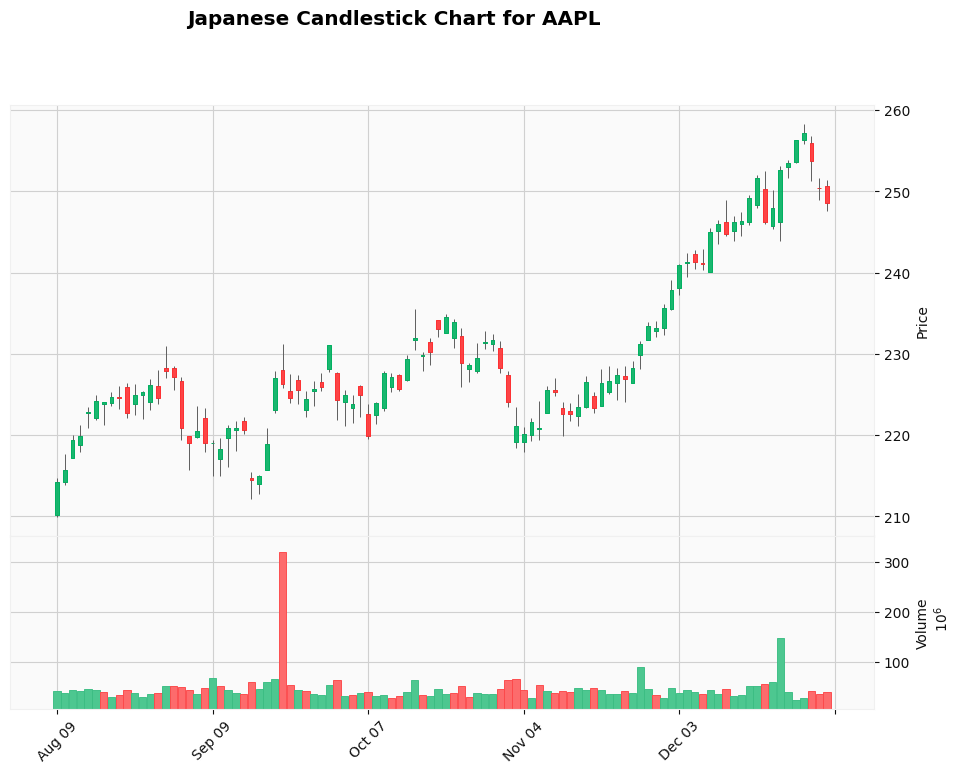

In [ ]:
import mplfinance as mpf

# Ensure the columns are in a format mplfinance expects
# If data.columns is a MultiIndex, flatten it. yfinance typically returns a MultiIndex
# for price columns like ('Open', 'AAPL'). mplfinance expects 'Open', 'High', 'Low', 'Close'.
# I will convert the column names to a single level if they are MultiIndex
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

# Plotting the candlestick chart
mpf.plot(
    data.tail(100),
    type='candle',
    style='yahoo',
    title=f"Japanese Candlestick Chart for {ticker}",
    ylabel='Price',
    ylabel_lower='Volume',
    volume=True,
    figscale=1.5
)

In [ ]:
import plotly.graph_objects as go

# Ensure the data index is set for plotting with Plotly
# Assuming 'Date' is the index, which is typical for yfinance dataframes

fig = go.Figure(data=[
    go.Candlestick(
        x=data.index,
        open=data['Open'],
        high=data['High'],
        low=data['Low'],
        close=data['Close']
    )
])

fig.update_layout(
    title_text=f'Interactive Japanese Candlestick Chart for {ticker}',
    xaxis_rangeslider_visible=True,
    xaxis_title='Date',
    yaxis_title='Price'
)

fig.show()

# Export the figure to an HTML file
fig.write_html("candlestick_chart.html")
print("Interactive candlestick chart exported as candlestick_chart.html")

Interactive candlestick chart exported as candlestick_chart.html


---

# 7. Conociendo nuestro DataFrame

Antes de calcular cualquier indicador, conviene inspeccionar los datos.

La regla práctica es:

> **Antes de modelar, primero entiende qué datos tienes.**

In [ ]:
data.head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2024-01-02,183.403976,186.170254,181.675055,184.895783,82488700
2024-01-03,182.030762,183.641134,181.220631,182.001124,58414500
2024-01-04,179.718948,180.884728,178.701356,179.956048,71983600
2024-01-05,178.997726,180.558698,177.999897,179.797983,62379700
2024-01-08,183.324966,183.364493,179.313871,179.896761,59144500


In [ ]:
data.tail()

Price,Close,High,Low,Open,Volume
Date,,,,,
2024-12-24,256.339752,256.349660,253.450699,253.649270,23234700
2024-12-26,257.153809,258.226044,255.773839,256.329802,27237100
2024-12-27,253.748550,256.836160,251.236779,255.972402,42355300
2024-12-30,250.382965,251.673602,248.943415,250.412748,35557500
2024-12-31,248.615784,251.455179,247.632911,250.621234,39480700


In [ ]:
data.shape

(252, 5)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 252 entries, 2024-01-02 to 2024-12-31
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   252 non-null    float64
 1   High    252 non-null    float64
 2   Low     252 non-null    float64
 3   Open    252 non-null    float64
 4   Volume  252 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 11.8 KB


In [ ]:
data.describe()

Price,Close,High,Low,Open,Volume
count,252.000000,252.000000,252.000000,252.000000,2.520000e+02
mean,205.280350,206.968684,203.309266,205.028862,5.710678e+07
std,25.530139,25.608398,25.161593,25.360322,3.072330e+07
min,163.220612,164.605508,162.310535,163.566871,2.323470e+07
25%,182.130783,183.267848,180.373893,181.671178,4.174738e+07
50%,212.241837,214.916848,209.943735,212.286392,4.983090e+07
75%,225.511047,227.462240,223.510280,225.594420,6.279472e+07
max,257.153809,258.226044,255.773839,256.329802,3.186799e+08


Al observar el DataFrame, pregúntate:

1. ¿Cuántas observaciones tenemos?
2. ¿Qué columnas existen?
3. ¿Hay valores faltantes?
4. ¿Qué rango de precios observamos?
5. ¿El volumen cambia mucho entre días?

---

# 8. Seleccionar información con pandas

Podemos seleccionar una sola columna:

In [ ]:
data["Close"].head()

,Close
Date,
2024-01-02,183.403976
2024-01-03,182.030762
2024-01-04,179.718948
2024-01-05,178.997726
2024-01-08,183.324966


O varias columnas:

In [ ]:
data[["Open", "High", "Low", "Close"]].head()

Price,Open,High,Low,Close
Date,,,,
2024-01-02,184.895783,186.170254,181.675055,183.403976
2024-01-03,182.001124,183.641134,181.220631,182.030762
2024-01-04,179.956048,180.884728,178.701356,179.718948
2024-01-05,179.797983,180.558698,177.999897,178.997726
2024-01-08,179.896761,183.364493,179.313871,183.324966


También podemos observar las últimas filas:

In [ ]:
data["Close"].tail(10)

,Close
Date,
2024-12-17,251.653732
2024-12-18,246.262863
2024-12-19,247.990326
2024-12-20,252.656479
2024-12-23,253.430847
2024-12-24,256.339752
2024-12-26,257.153809
2024-12-27,253.748550
2024-12-30,250.382965


---

# 9. Primer gráfico financiero

Visualizar el precio nos permite entender rápidamente la trayectoria del activo.

<Axes: xlabel='Date'>

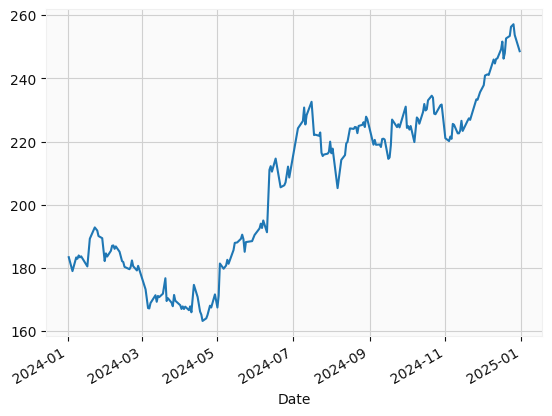

In [ ]:
data["Close"].plot()

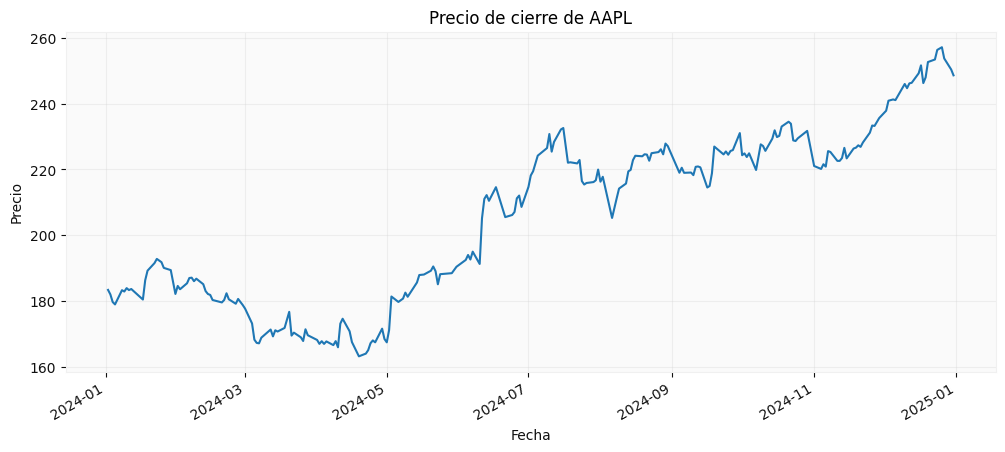

In [ ]:
data["Close"].plot(figsize=(12, 5))

plt.title("Precio de cierre de AAPL")
plt.xlabel("Fecha")
plt.ylabel("Precio")
plt.grid(alpha=0.3)
plt.show()

## Pregunta para reflexionar

Observando solamente el gráfico:

- ¿El precio terminó más alto o más bajo?
- ¿Hubo periodos de caída?
- ¿El crecimiento fue constante?
- ¿Podemos decir que fue una “buena inversión” solo viendo el precio?

La última pregunta nos lleva a una idea fundamental:

> **En finanzas no solo importa el nivel del precio. También importa cómo cambia.**

---

# 10. Del precio al retorno

El retorno simple de un periodo se define como:

$$
R_t = \frac{P_t}{P_{t-1}} - 1
$$

Si:

$$
P_{t-1}=100
$$

y:

$$
P_t=105
$$

entonces:

$$
R_t = \frac{105}{100}-1 = 0.05 = 5\%
$$

En pandas podemos calcular esta variación mediante `pct_change()`.

In [ ]:
data["Close"]

,Close
Date,
2024-01-02,183.403976
2024-01-03,182.030762
2024-01-04,179.718948
2024-01-05,178.997726
2024-01-08,183.324966
...,...
2024-12-24,256.339752
2024-12-26,257.153809
2024-12-27,253.748550


In [ ]:
data["Return"] = data["Close"].pct_change()

data[["Close", "Return"]].head()

Price,Close,Return
Date,,
2024-01-02,183.403976,NaN
2024-01-03,182.030762,-0.007487
2024-01-04,179.718948,-0.012700
2024-01-05,178.997726,-0.004013
2024-01-08,183.324966,0.024175


## Media de retornos

Una primera medida descriptiva es el retorno promedio:

$$
\bar{R} = \frac{1}{n}\sum_{t=1}^{n} R_t
$$

In [ ]:
data["Return"].describe()

,Return
count,251.000000
mean,0.001312
std,0.014123
min,-0.048167
25%,-0.006713
50%,0.001596
75%,0.009332
max,0.072649


In [ ]:
retorno_promedio = data["Return"].mean()

print("Retorno diario promedio:", retorno_promedio)
print(f"Retorno diario promedio: {retorno_promedio:.4%}")

Retorno diario promedio: 0.0013115517556155783
Retorno diario promedio: 0.1312%


## Dispersión de los retornos

Una forma básica de medir cuánto varían los retornos es la desviación estándar:

$$
s =
\sqrt{
\frac{
\sum_{t=1}^{n}(R_t-\bar{R})^2
}{
n-1
}
}
$$

En esta primera clase la interpretaremos de forma sencilla:

> Una desviación estándar mayor significa que los retornos presentan más variación.

$$
s =
\sqrt{
\frac{
\sum_{t=1}^{n}(R_t-\bar{R})^2
}{
n-1
}
}
$$

In [ ]:
desviacion = data["Return"].std()

print("Desviación estándar diaria:", desviacion)
print(f"Desviación estándar diaria: {desviacion:.4%}")

Desviación estándar diaria: 0.014123080935567101
Desviación estándar diaria: 1.4123%


---

# 11. Precio vs. retornos

El precio y el retorno responden preguntas diferentes.

### Precio
Nos muestra el nivel del activo a lo largo del tiempo.

### Retorno
Nos muestra cuánto cambió el precio de un periodo al siguiente.

In [ ]:
ticker

'AAPL'

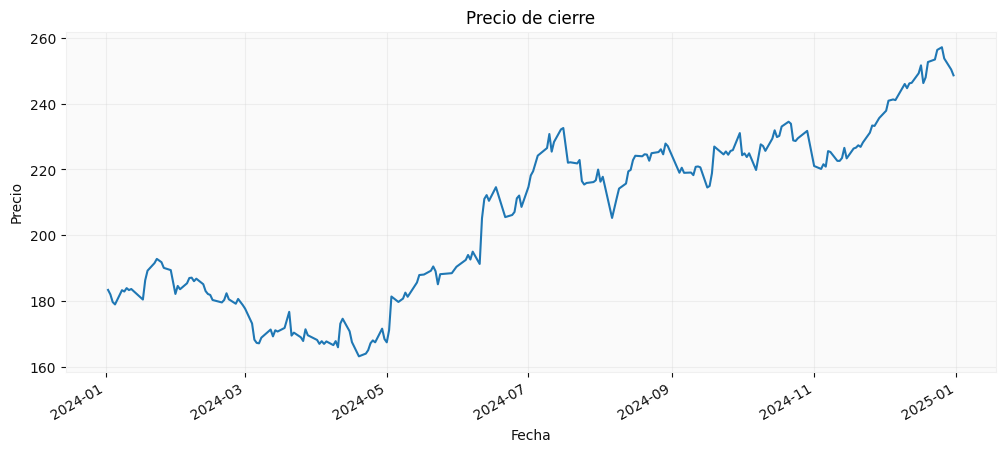

In [ ]:
data["Close"].plot(figsize=(12, 5))

plt.title("Precio de cierre")
plt.xlabel("Fecha")
plt.ylabel("Precio")
plt.grid(alpha=0.3)
plt.show()

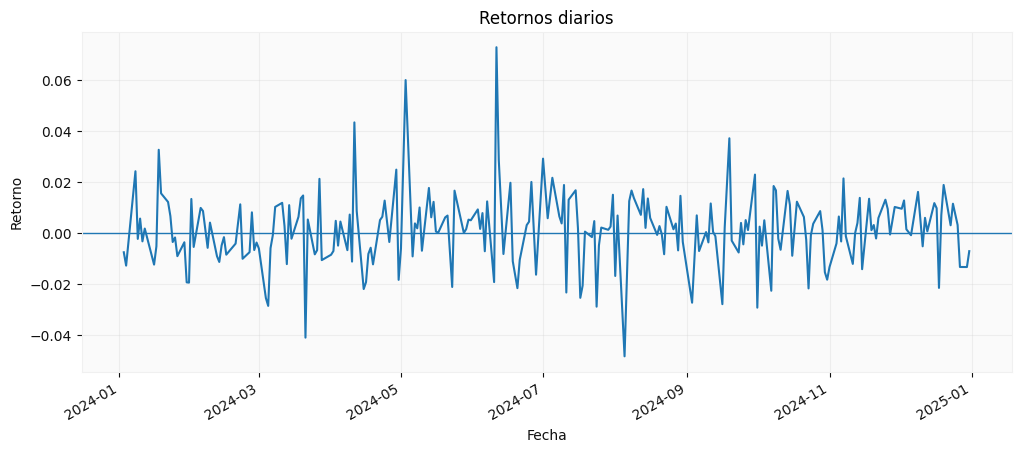

In [ ]:
data["Return"].plot(figsize=(12, 5))

plt.title("Retornos diarios")
plt.xlabel("Fecha")
plt.ylabel("Retorno")
plt.axhline(0, linewidth=1)
plt.grid(alpha=0.3)
plt.show()

### Observación

Es común que un precio muestre una tendencia clara mientras que los retornos se vean mucho más variables.

Esta diferencia será importante cuando avancemos hacia:

- análisis de riesgo,
- distribuciones,
- volatilidad,
- modelos estadísticos,
- series de tiempo.

---

# 12. Primera transformación: media móvil

Una media móvil suaviza el precio utilizando las últimas$k$ observaciones.

Para una ventana de$k$ periodos:

$$
MA_t^{(k)}
=
\frac{1}{k}
\sum_{i=0}^{k-1}P_{t-i}
$$

Por ejemplo, una media móvil de 20 días utiliza los últimos 20 precios disponibles.

In [ ]:
data.to_excel("apple.xlsx")

In [ ]:
data["Close"].rolling(3).mean()

,Close
Date,
2024-01-02,NaN
2024-01-03,NaN
2024-01-04,181.717896
2024-01-05,180.249146
2024-01-08,180.680547
...,...
2024-12-24,254.142359
2024-12-26,255.641469
2024-12-27,255.747370


In [ ]:
data["SMA20"] = data["Close"].rolling(20).mean()

data[["Close", "SMA20"]].tail()

Price,Close,SMA20
Date,,
2024-12-24,256.339752,244.519021
2024-12-26,257.153809,245.708389
2024-12-27,253.748550,246.733947
2024-12-30,250.382965,247.472091
2024-12-31,248.615784,248.009689


SMA20: Es el promedio movil del precio de la acción.

Tendencias de corto plazo: 20 periodos

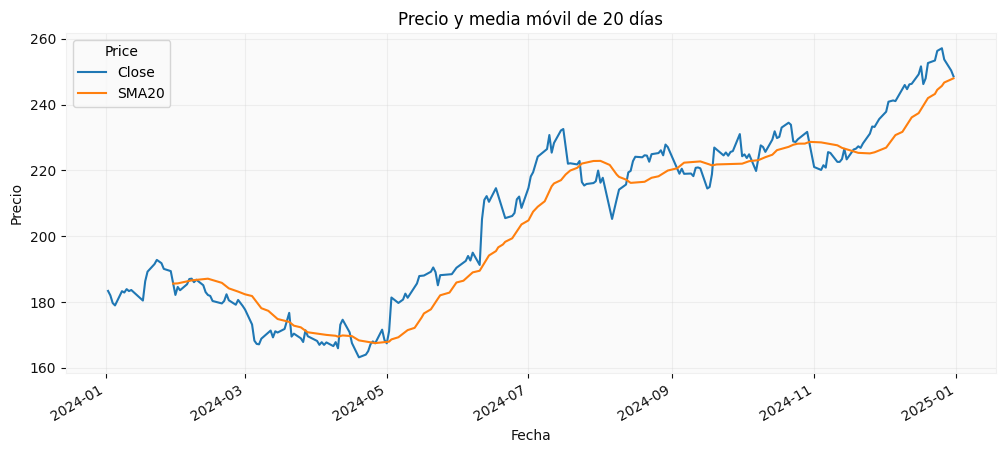

In [ ]:
data[["Close", "SMA20"]].plot(figsize=(12, 5))

plt.title("Precio y media móvil de 20 días")
plt.xlabel("Fecha")
plt.ylabel("Precio")
plt.grid(alpha=0.3)
plt.show()

---

# 13. Convertir una idea en una regla

Supongamos que queremos construir una regla extremadamente sencilla:

$$
Signal_t =
\begin{cases}
1, & \text{si } P_t > SMA20_t \\
-1, & \text{si } P_t < SMA20_t \\
0, & \text{en otro caso}
\end{cases}
$$

Interpretación didáctica:

- `1` → condición favorable.
- `-1` → condición contraria.
- `0` → sin señal.

Por ahora no afirmaremos que esta regla sea rentable.

In [ ]:
data["Signal"] = 0

In [ ]:
data["Close"] > data["SMA20"]#evaluacion fila a fila de la señal Pt > SMA20

,0
Date,
2024-01-02,False
2024-01-03,False
2024-01-04,False
2024-01-05,False
2024-01-08,False
...,...
2024-12-24,True
2024-12-26,True
2024-12-27,True


In [ ]:
data.loc[:,'Close']

,Close
Date,
2024-01-02,183.403976
2024-01-03,182.030762
2024-01-04,179.718948
2024-01-05,178.997726
2024-01-08,183.324966
...,...
2024-12-24,256.339752
2024-12-26,257.153809
2024-12-27,253.748550


In [ ]:
data.loc[data["Close"] > data["SMA20"], "Signal"]

,Signal
Date,
2024-01-30,0
2024-02-06,0
2024-02-07,0
2024-03-19,0
2024-03-20,0
...,...
2024-12-24,0
2024-12-26,0
2024-12-27,0


In [ ]:
data.loc[data["Close"] > data["SMA20"], "Signal"] = 1
#el valor de 1, se inserta en las filas que cumplen el filtro y la columna seleccionada

In [ ]:
#data["Signal"] = 0
#data.loc[data["Close"] > data["SMA20"], "Signal"] = 1
#data.loc[data["Close"] < data["SMA20"], "Signal"] = -1

In [ ]:
data.loc[data["Close"] < data["SMA20"], "Signal"] = -1

data[["Close", "SMA20", "Signal"]].tail(10)

Price,Close,SMA20,Signal
Date,,,
2024-12-17,251.653732,238.698259,1
2024-12-18,246.262863,239.679637,1
2024-12-19,247.990326,240.711648,1
2024-12-20,252.656479,242.000793,1
2024-12-23,253.430847,243.261644,1
2024-12-24,256.339752,244.519021,1
2024-12-26,257.153809,245.708389,1
2024-12-27,253.748550,246.733947,1
2024-12-30,250.382965,247.472091,1


Podemos contar cuántos días aparecen en cada estado:

In [ ]:
data["Signal"].value_counts()

,count
Signal,
1,141
-1,92
0,19


---

# 14. De una regla a una estrategia

Hasta aquí tenemos:

$$
\text{Precio}
\rightarrow
\text{Indicador}
\rightarrow
\text{Regla}
\rightarrow
\text{Señal}
$$

Pero todavía faltan preguntas importantes:

- ¿Cuándo exactamente se entra al mercado?
- ¿Cuánto capital se utiliza?
- ¿Qué ocurre con los costos de transacción?
- ¿Qué ocurre con el slippage?
- ¿Cómo evitamos usar información futura?
- ¿Cuál fue el riesgo asumido?
- ¿Cómo comparamos la estrategia con un benchmark?
- ¿Funcionó solamente en el periodo analizado?
- ¿Funciona fuera de muestra?

Estas preguntas nos llevan al concepto de **backtesting** y, más adelante, a la validación robusta de estrategias.

---

# 15. Vista previa: rendimiento de una estrategia

La siguiente sección es solamente una **vista previa**.

Si una señal tomada al final del día$t-1$ define la posición que mantenemos durante el día$t$, podemos representar de forma simplificada el retorno de una estrategia como:

$$
R_{t}^{estrategia}
=
Signal_{t-1}\cdot R_t
$$

El desplazamiento de la señal es importante:

$$
Signal_{t-1}
$$

porque evita utilizar una señal del mismo periodo como si hubiéramos conocido su resultado de antemano.

> En clases posteriores estudiaremos esta lógica con mucho más detalle.

Metodo de rezago: `shift()`

In [ ]:
data['Close'].shift(1)

,Close
Date,
2024-01-02,NaN
2024-01-03,183.403976
2024-01-04,182.030762
2024-01-05,179.718948
2024-01-08,178.997726
...,...
2024-12-24,253.430847
2024-12-26,256.339752
2024-12-27,257.153809


In [ ]:
data["Strategy_Return"] = data["Signal"].shift(1) * data["Return"]

In [ ]:
data[["Return", "Signal", "Strategy_Return"]].tail()

Price,Return,Signal,Strategy_Return
Date,,,
2024-12-24,0.011478,1,0.011478
2024-12-26,0.003176,1,0.003176
2024-12-27,-0.013242,1,-0.013242
2024-12-30,-0.013263,1,-0.013263
2024-12-31,-0.007058,1,-0.007058


Podemos construir una curva acumulada sencilla:

$$
V_t = \prod_{i=1}^{t}(1 + R_i)
$$

In [ ]:
crecimiento_activo = (1 + data["Return"].fillna(0)).cumprod()
crecimiento_estrategia = (1 + data["Strategy_Return"].fillna(0)).cumprod()

In [ ]:
comparacion = pd.DataFrame({
    "Activo": crecimiento_activo,
    "Estrategia": crecimiento_estrategia
})

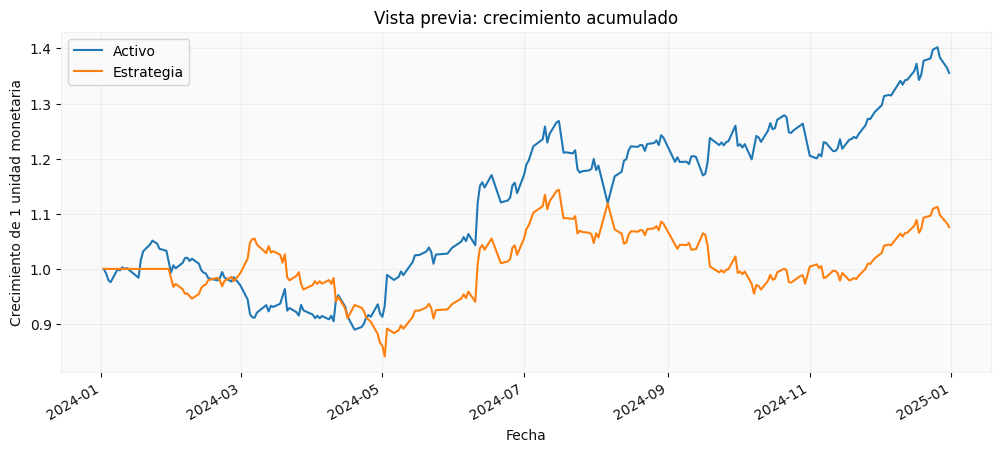

In [ ]:
comparacion.plot(figsize=(12, 5))

plt.title("Vista previa: crecimiento acumulado")
plt.xlabel("Fecha")
plt.ylabel("Crecimiento de 1 unidad monetaria")
plt.grid(alpha=0.3)
plt.show()

## Advertencia importante

Este gráfico **no demuestra** que la estrategia sea buena.

Todavía no estamos considerando de forma completa:

- costos,
- slippage,
- sesgos,
- estabilidad,
- sensibilidad,
- validación fuera de muestra,
- comparación de riesgo.

La intención de esta sección es únicamente mostrar el camino que recorreremos durante el programa.

---

# 16. El flujo completo de esta primera clase

Hoy recorrimos este camino:

$$
\boxed{
\text{Python}
\rightarrow
\text{Datos financieros}
\rightarrow
\text{Exploración}
\rightarrow
\text{Gráficos}
\rightarrow
\text{Retornos}
\rightarrow
\text{Indicador}
\rightarrow
\text{Regla}
}
$$

Más adelante avanzaremos hacia:

$$
\boxed{
\text{Señales}
\rightarrow
\text{Posiciones}
\rightarrow
\text{Backtesting}
\rightarrow
\text{Riesgo}
\rightarrow
\text{Validación}
\rightarrow
\text{Estrategia reproducible}
}
$$

---

# 17. Ejercicios propuestos

## Ejercicio 1 — Cambiar de activo

Reemplaza `AAPL` por otro ticker.

Ejemplos:

- `MSFT`
- `GOOGL`
- `AMZN`
- `NVDA`

Preguntas:

1. ¿El comportamiento del precio es similar?
2. ¿Los retornos parecen más o menos variables?
3. ¿La señal cambia con frecuencia?

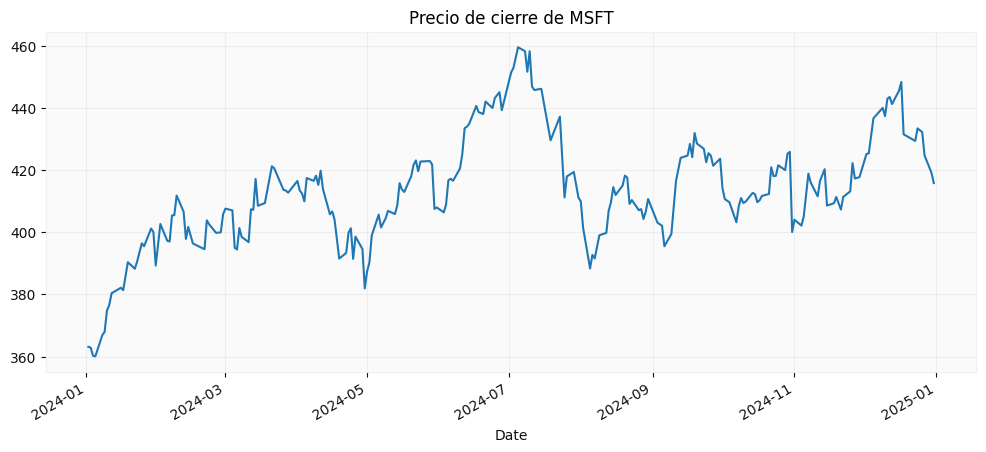

In [ ]:
ticker = "MSFT"

otro_activo = yf.download(
    ticker,
    start="2024-01-01",
    end="2025-01-01",
    auto_adjust=True,
    progress=False
)

if isinstance(otro_activo.columns, pd.MultiIndex):
    otro_activo.columns = otro_activo.columns.get_level_values(0)

otro_activo["Close"].plot(figsize=(12, 5))
plt.title(f"Precio de cierre de {ticker}")
plt.grid(alpha=0.3)
plt.show()

## Ejercicio 2 — Cambiar la ventana de la media móvil

Prueba con:

- 10 días,
- 20 días,
- 50 días.

La fórmula general sigue siendo:

$$
MA_t^{(k)}
=
\frac{1}{k}
\sum_{i=0}^{k-1}P_{t-i}
$$

Observa cómo cambia la suavidad del indicador.

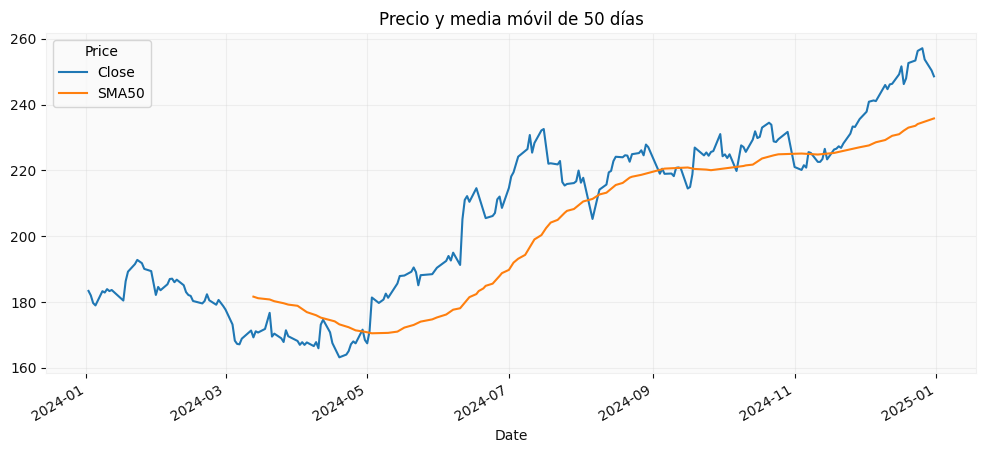

In [ ]:
ventana = 50

data[f"SMA{ventana}"] = data["Close"].rolling(ventana).mean()

data[["Close", f"SMA{ventana}"]].plot(figsize=(12, 5))
plt.title(f"Precio y media móvil de {ventana} días")
plt.grid(alpha=0.3)
plt.show()

## Ejercicio 3

Analiza las diferentes medias moviles en sub graficos

/usr/local/lib/python3.13/dist-packages/pandas/plotting/_matplotlib/core.py:981: UserWarning:

This axis already has a converter set and is updating to a potentially incompatible converter



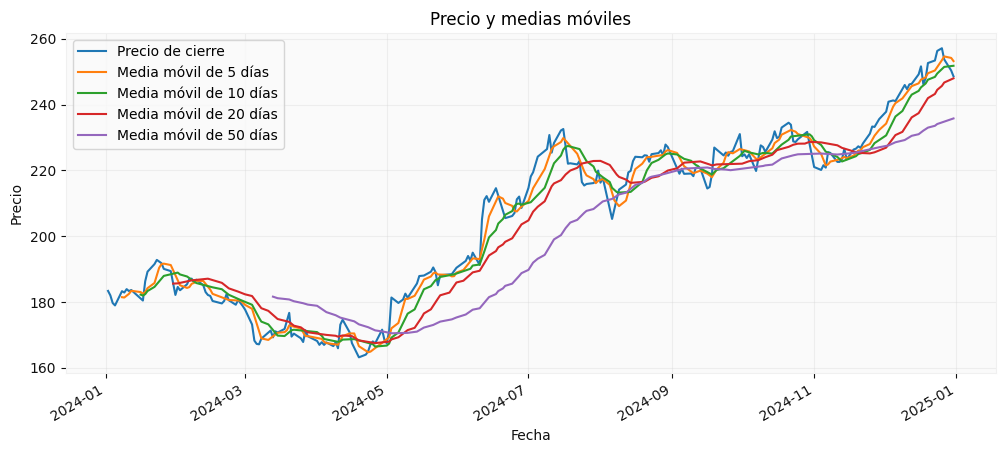

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(data["Close"], label="Precio de cierre")
data["Close"].rolling(5).mean().plot(label="Media móvil de 5 días")
data["Close"].rolling(10).mean().plot(label="Media móvil de 10 días")
data["Close"].rolling(20).mean().plot(label="Media móvil de 20 días")
data["Close"].rolling(50).mean().plot(label="Media móvil de 50 días")
plt.title("Precio y medias móviles")
plt.xlabel("Fecha")
plt.ylabel("Precio")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## ¿Optimizando K?

In [ ]:
data_k = data[["Close"]].copy()
data_k["Return"] = data_k["Close"].pct_change()
crecimiento_activo = (1 + data_k["Return"].fillna(0)).cumprod()
data_k['Activo'] = crecimiento_activo

In [ ]:
# definiendo el valor de K
k = 11#este valor cambiara
# media movil en K
name = str(k) if k >= 10 else '0' + str(k)
data_k['SMA' + name] = data_k['Close'].rolling(k).mean()
# se define signo
data_k["Signal_"+name] = 0
data_k.loc[data_k["Close"] > data_k["SMA"+ name], "Signal_" + name] = 1
data_k.loc[data_k["Close"] < data_k["SMA"+ name], "Signal_" + name] = -1
# se define rendimiento
data_k["Strategy_Return_"+name] = data_k["Signal_"+name].shift(1) * data_k["Return"]
# calcula el redimiento acumulado
crecimiento_activo = (1 + data_k["Return"].fillna(0)).cumprod()
crecimiento_estrategia = (1 + data_k["Strategy_Return_"+name].fillna(0)).cumprod()
data_k['Estrategia_'+name] = crecimiento_estrategia

In [ ]:
resultado = float(data_k['Estrategia_'+name][-1] - data_k['Activo'][-1])
resultado

/tmp/ipykernel_2216/2969754550.py:1: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



-0.35322697891583665

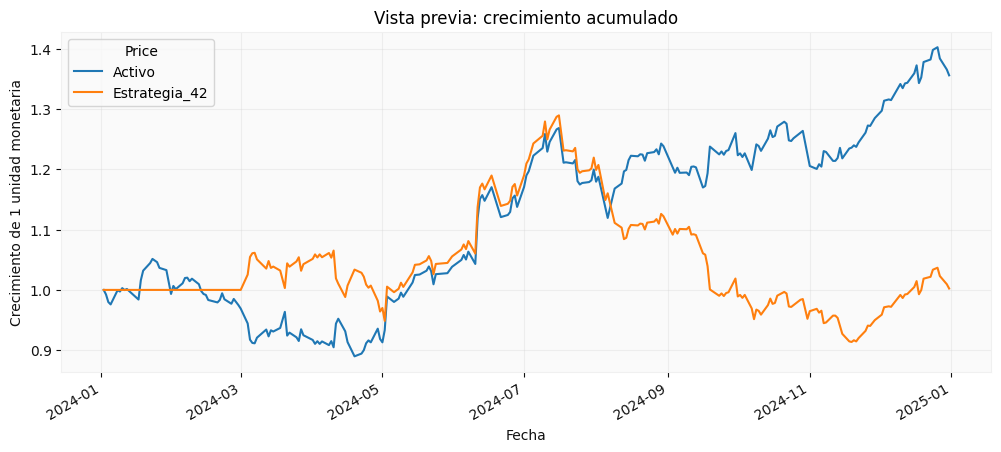

In [ ]:
data_k[['Activo','Estrategia_'+name]].plot(figsize=(12, 5))

plt.title("Vista previa: crecimiento acumulado")
plt.xlabel("Fecha")
plt.ylabel("Crecimiento de 1 unidad monetaria")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
rango_k = range(5,51)
l_resultados = []
for k in rango_k:
  # media movil en K
  name = str(k) if k >= 10 else '0' + str(k)
  data_k['SMA' + name] = data_k['Close'].rolling(k).mean()
  # se define signo
  data_k["Signal_"+name] = 0
  data_k.loc[data_k["Close"] > data_k["SMA"+ name], "Signal_" + name] = 1
  data_k.loc[data_k["Close"] < data_k["SMA"+ name], "Signal_" + name] = -1
  # se define rendimiento
  data_k["Strategy_Return_"+name] = data_k["Signal_"+name].shift(1) * data_k["Return"]
  # calcula el redimiento acumulado
  crecimiento_activo = (1 + data_k["Return"].fillna(0)).cumprod()
  crecimiento_estrategia = (1 + data_k["Strategy_Return_"+name].fillna(0)).cumprod()
  data_k['Estrategia_'+name] = crecimiento_estrategia
  resultado = float(data_k['Estrategia_'+name][-1] - data_k['Activo'][-1])
  l_resultados.append(resultado)

<Axes: xlabel='k'>

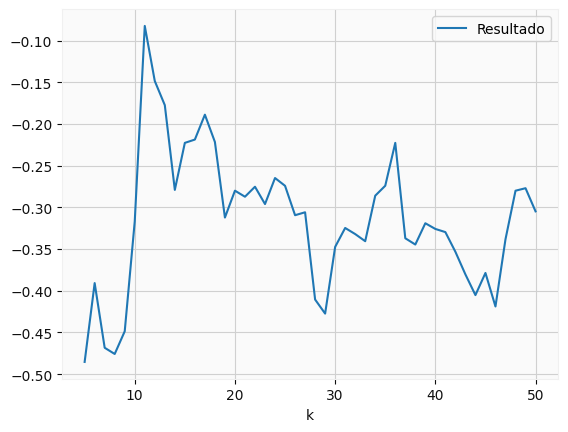

In [ ]:
tabla_resultados = pd.DataFrame({'k':rango_k,'Resultado':l_resultados})
tabla_resultados.plot(x='k',y='Resultado')

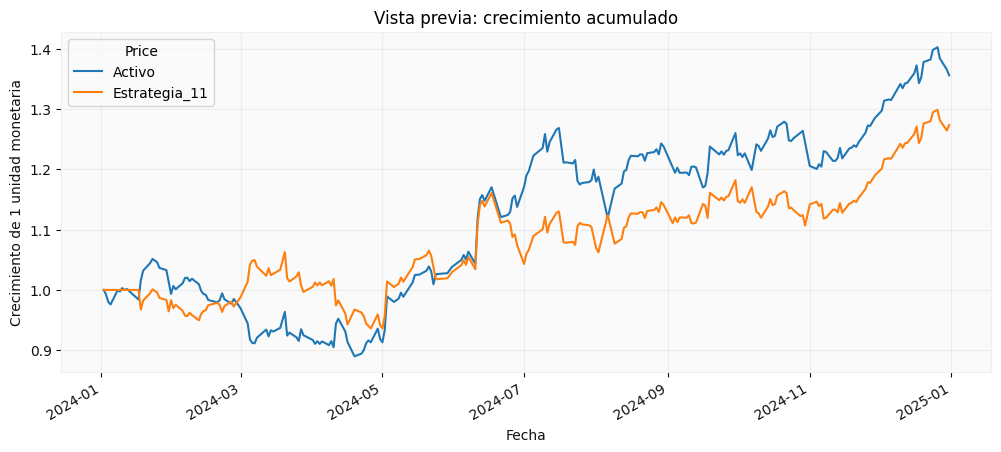

In [ ]:
data_k[['Activo','Estrategia_'+'11']].plot(figsize=(12, 5))

plt.title("Vista previa: crecimiento acumulado")
plt.xlabel("Fecha")
plt.ylabel("Crecimiento de 1 unidad monetaria")
plt.grid(alpha=0.3)
plt.show()


---

# 18. Cierre de la clase

La idea más importante de esta sesión no es una fórmula ni una línea de código.

Es comprender el proceso:

> **Los datos describen el mercado.  
> Python nos permite analizarlos.  
> Una regla transforma una idea en una señal.  
> Pero una señal todavía debe ser evaluada rigurosamente.**

Durante el primer módulo construiremos una base común en:

- Python,
- datos financieros,
- retornos,
- riesgo,
- métricas,
- regresión,
- series de tiempo.

Esta base nos permitirá avanzar posteriormente hacia modelado cuantitativo, Machine Learning y backtesting con mayor rigor.